# Spatial Search by Discrete-time Quantum Walk

This notebook implements spatial search on a square lattice using a coined discrete-time quantum walk in Qmod. The construction is based on the coined quantum-walk search algorithm introduced by Ambainis et al. in “Coins Make Quantum Walks Faster.” (Ref.[[1](#CoinsMakeQuantumWalksFaster)])

The main motivation is quantum speedup for spatial search. Classically, finding a marked vertex among $N$ vertices requires $\mathcal{O}(N)$ queries in an unstructured search setting. Ambainis et al. showed that a coined discrete-time quantum walk can find a marked vertex on a two-dimensional grid in $\mathcal{O}(\sqrt{N}\log N)$ steps, and on grids of dimension three or higher in $\mathcal{O}(\sqrt{N})$ steps. Thus, the coined quantum walk provides a quadratic-type speedup over classical search, up to a logarithmic factor in two dimensions.  In this sense, the algorithm can be viewed as a spatially constrained analogue of Grover search: both use a phase oracle and interference to amplify the marked state, but the quantum walk respects the local connectivity of the lattice through the coin and shift operators.


In this algorithm, the oracle marks the target vertex by applying a phase flip to it. The Grover coin mixes the coin amplitudes locally, while the flip-flop shift propagates amplitudes across the lattice. Repeating these operations causes constructive and destructive interference that concentrates probability around the marked vertex, which can then be detected by measurement.

Such quantum-walk operators can be described intuitively using Qmod.  In this notebook, we compare the probability distribution sampled from the Qmod circuit with the result of a direct statevector calculation for the following two boundary conditions:

1. Periodic boundary conditions, where the lattice is treated as a torus.
2. Non-periodic boundary conditions, where moves outside the boundary are not allowed.

The goal is not only to obtain a high probability at the marked vertex.  We also verify that the Qmod circuit reproduces the intended walk dynamics over the full probability distribution, not just at the marked vertex.


## Walk Model

![png](figures/flip_flop_walk.png)

We follow the discrete-time flip-flop quantum-walk search model used in the paper.
The Hilbert space is

$$
\mathcal{H}=\mathcal{H}_{x}\otimes \mathcal{H}_{C}.
$$

For a $d$-dimensional lattice, each vertex has degree $k=2d$, and the coin label $l=0,\ldots,k-1$ specifies one of the possible directions. The state at time $t$ is

$$
|\Psi(t)\rangle
=
\sum_{x\in V}
\sum_{l=0}^{k-1}
\psi_{x,l}(t)
|x\rangle |l\rangle .
$$

In this notebook, we mainly consider a two-dimensional $L\times L$ square lattice, where $d=2$, $k=4$, and $N=L^2$. The coin states are encoded as

$$
|0\rangle:-x,\qquad
|1\rangle:+x,\qquad
|2\rangle:-y,\qquad
|3\rangle:+y.
$$

More generally, the pair for axis $j$ is $|2j\rangle,|2j+1\rangle$, where the first state represents the negative direction and the second the positive direction. Thus the opposite direction is obtained by flipping the last bit of the coin register:

$$
|0\rangle \leftrightarrow |1\rangle,
\qquad
|2\rangle \leftrightarrow |3\rangle .
$$

At the circuit level, this flip is implemented by a single $X$ gate on the least significant coin qubit.

The initial state is the uniform superposition over all valid position and coin states,

$$
|\Psi(0)\rangle
=
\frac{1}{\sqrt{Nk}}
\sum_{x\in V}
\sum_{l=0}^{k-1}
|x\rangle |l\rangle .
$$

For a two-dimensional $L\times L$ lattice,

$$
|\Psi(0)\rangle
=
\frac{1}{2L}
\sum_{x=0}^{L-1}
\sum_{y=0}^{L-1}
\sum_{c=0}^{3}
|x,y\rangle |c\rangle .
$$

Equivalently,

$$
|\Psi(0)\rangle
=
\left(
\frac{1}{L}
\sum_{x=0}^{L-1}
\sum_{y=0}^{L-1}
|x,y\rangle
\right)
\otimes
|s\rangle,
\qquad
|s\rangle
=
\frac{1}{2}
\sum_{c=0}^{3}
|c\rangle .
$$

When $L$ is a power of two, this state can be prepared by Hadamard gates on the position and coin registers. For other lattice sizes, padded computational-basis states must be excluded.

The marked vertex is denoted by

$$
x_0=(x_w,y_w).
$$

The oracle applies a phase flip to all coin states at the marked position,

$$
\hat{R}
=
\left(
\hat{I}_{x}
-
2|x_0\rangle\langle x_0|
\right)
\otimes
\hat{I}_{C}.
$$

The coin operator is

$$
\hat{C}
=
\hat{I}_{x}\otimes \hat{G},
$$

where $\hat{G}$ is the Grover diffusion operator on the coin space,

$$
\hat{G}
=
2|s\rangle\langle s|-\hat{I}_{C},
\qquad
|s\rangle
=
\frac{1}{\sqrt{k}}
\sum_{l=0}^{k-1}
|l\rangle .
$$

For $d=2$, this becomes

$$
|s\rangle
=
\frac{1}{2}
\left(
|0\rangle+|1\rangle+|2\rangle+|3\rangle
\right),
$$

and

$$
\hat{G}
=
\frac{1}{2}
\begin{pmatrix}
-1 & 1 & 1 & 1 \\
1 & -1 & 1 & 1 \\
1 & 1 & -1 & 1 \\
1 & 1 & 1 & -1
\end{pmatrix}.
$$

The walk operator is

$$
\hat{W}
=
\hat{S}\hat{C},
$$

where $\hat{S}$ is the flip-flop shift. One search iteration applies the oracle followed by the walk operator:

$$
|\Psi(t)\rangle
=
\left[
\hat{W}\hat{R}
\right]^t
|\Psi(0)\rangle
=
\left[
\hat{S}\hat{C}\hat{R}
\right]^t
|\Psi(0)\rangle .
$$

### Periodic boundary conditions

For periodic boundary conditions, the shift moves the walker according to the coin state and then flips the direction:

$$
\begin{aligned}
\hat{S}|x,y\rangle |0\rangle
&=
|x-1 \bmod L, y\rangle |1\rangle, \\
\hat{S}|x,y\rangle |1\rangle
&=
|x+1 \bmod L, y\rangle |0\rangle, \\
\hat{S}|x,y\rangle |2\rangle
&=
|x, y-1 \bmod L\rangle |3\rangle, \\
\hat{S}|x,y\rangle |3\rangle
&=
|x, y+1 \bmod L\rangle |2\rangle .
\end{aligned}
$$

Equivalently,

$$
\hat{S}
=
\left(
\hat{I}\otimes \hat{S}_{\mathrm{flip}}
\right)
\hat{S}_{\mathrm{move}},
$$

where

$$
\hat{S}_{\mathrm{move}} |x\rangle |l\rangle
=
|x+\delta_l\rangle |l\rangle,
\qquad
\hat{S}_{\mathrm{flip}} |l\rangle
=
|\bar{l}\rangle .
$$

For the two-dimensional encoding,

$$
\bar{0}=1,\qquad
\bar{1}=0,\qquad
\bar{2}=3,\qquad
\bar{3}=2.
$$

In the circuit implementation, $\hat{S}_{\mathrm{move}}$ is realized by coin-controlled modular increment and decrement operations on the position registers, while $\hat{S}_{\mathrm{flip}}$ is the $X$ gate on the least significant coin qubit.

### Non-periodic boundary conditions

For non-periodic boundary conditions, moves that would leave the lattice are blocked. In the model used in the paper, such moves are treated as self-loops:

$$
\hat{S}|x\rangle |l\rangle
=
\begin{cases}
|x+\delta_l\rangle |\bar{l}\rangle,
&
x+\delta_l\in V, \
|x\rangle |l\rangle,
&
x+\delta_l\notin V .
\end{cases}
$$

For the two-dimensional square lattice, the move-validity flag is

$$
a(x,y,l)=1
\Longleftrightarrow
\begin{cases}
x>0, & l=0,\\
x<L-1, & l=1,\\
y>0, & l=2,\\
y<L-1, & l=3.
\end{cases}
$$

In the circuit implementation, this flag is computed from the current position and coin state at every walk step. The move and flip operations are applied only when $a(x,y,l)=1$, and the flag is then uncomputed. Recomputing the flag at each step is necessary to avoid using stale boundary information.

The probability of measuring vertex $x$ at time $t$ is obtained by summing over all coin states:

$$
P(x,t)
=
\sum_{l=0}^{k-1}
\left|
\langle x,l|\Psi(t)\rangle
\right|^2 .
$$

For the two-dimensional lattice,

$$
P_t(x,y)
=
\sum_{c=0}^{3}
\left|
\langle x,y,c|\Psi(t)\rangle
\right|^2 .
$$

The target-site success probability is

$$
P(x_0,t)
=
\sum_{c=0}^{3}
\left|
\langle x_w,y_w,c|\Psi(t)\rangle
\right|^2 .
$$

In this notebook, we compare the target-site probability and the full position probability distribution obtained from the Qmod implementation with those obtained from a direct statevector calculation.


In [19]:
import itertools
import math
import time

import matplotlib.pyplot as plt
import numpy as np

from classiq import *

In [20]:
d = 2
L = d**3
N = L**d
k = 4
nx = int(np.ceil(np.log2(L)))
nl = int(np.ceil(np.log2(k)))

marked_vertex = (L // 2, L // 2)
selected_steps = [1, 10, 20, 30, 40, 50, 60, 70]
comparison_step = 10
NUM_SHOTS = 1024

print(f"L = {L}, N = {N}, nx = {nx}, nl = {nl}")
print(f"marked vertex = {marked_vertex}")

L = 8, N = 64, nx = 3, nl = 2
marked vertex = (4, 4)


## Direct Statevector Calculation

Before building the Qmod circuit, we define a compact direct simulator.  

In [21]:
GROVER_COIN = (
    np.array(
        [
            [-1, 1, 1, 1],
            [1, -1, 1, 1],
            [1, 1, -1, 1],
            [1, 1, 1, -1],
        ],
        dtype=complex,
    )
    / 2
)


def position_probability(psi):
    return np.sum(np.abs(psi) ** 2, axis=2).real


def apply_flip_flop_shift_periodic(psi):
    L = psi.shape[0]
    next_psi = np.zeros_like(psi)

    for x, y in itertools.product(range(L), range(L)):
        next_psi[(x - 1) % L, y, 1] += psi[x, y, 0]
        next_psi[(x + 1) % L, y, 0] += psi[x, y, 1]
        next_psi[x, (y - 1) % L, 3] += psi[x, y, 2]
        next_psi[x, (y + 1) % L, 2] += psi[x, y, 3]

    return next_psi


def apply_flip_flop_shift_nonperiodic(psi):
    L = psi.shape[0]
    next_psi = np.zeros_like(psi)

    for x, y in itertools.product(range(L), range(L)):
        if x > 0:
            next_psi[x - 1, y, 1] += psi[x, y, 0]
        else:
            next_psi[x, y, 0] += psi[x, y, 0]

        if x < L - 1:
            next_psi[x + 1, y, 0] += psi[x, y, 1]
        else:
            next_psi[x, y, 1] += psi[x, y, 1]

        if y > 0:
            next_psi[x, y - 1, 3] += psi[x, y, 2]
        else:
            next_psi[x, y, 2] += psi[x, y, 2]

        if y < L - 1:
            next_psi[x, y + 1, 2] += psi[x, y, 3]
        else:
            next_psi[x, y, 3] += psi[x, y, 3]

    return next_psi


def simulate_walk_reference(boundary, num_steps, snapshots=()):
    if boundary not in {"periodic", "nonperiodic"}:
        raise ValueError("boundary must be 'periodic' or 'nonperiodic'")

    shift = (
        apply_flip_flop_shift_periodic
        if boundary == "periodic"
        else apply_flip_flop_shift_nonperiodic
    )

    psi = np.ones((L, L, k), dtype=complex) / np.sqrt(L * L * k)
    marked_probs = [float(position_probability(psi)[marked_vertex])]
    snapshot_set = set(snapshots)
    snapshot_probs = {0: position_probability(psi)} if 0 in snapshot_set else {}

    for step in range(1, num_steps + 1):
        psi[marked_vertex] *= -1
        psi = np.einsum("ab,xyb->xya", GROVER_COIN, psi)
        psi = shift(psi)

        prob = position_probability(psi)
        marked_probs.append(float(prob[marked_vertex]))
        if step in snapshot_set:
            snapshot_probs[step] = prob

    return np.array(marked_probs), snapshot_probs


def plot_probability_maps(direct_prob, qmod_prob, title):
    vmax = max(float(direct_prob.max()), float(qmod_prob.max()))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    panels = [
        (direct_prob, "direct calculation", vmax),
        (qmod_prob, "Qmod samples", vmax),
    ]

    for ax, (data, label, local_vmax) in zip(axes, panels):
        im = ax.imshow(data.T, origin="lower", cmap="viridis", vmin=0, vmax=local_vmax)
        ax.scatter(*marked_vertex, marker="x", color="white", s=90, linewidths=2)
        ax.set_title(label)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(title)
    plt.show()


def plot_marked_probability(time_axis, direct_curve, sampled_rows, title):
    plt.figure(figsize=(8, 4.5))
    plt.plot(
        time_axis, direct_curve, color="black", linewidth=2, label="direct calculation"
    )
    plt.scatter(
        [row["t"] for row in sampled_rows],
        [row["probability"] for row in sampled_rows],
        color="crimson",
        s=70,
        label="Qmod samples",
        zorder=3,
    )
    plt.xlabel("walk step")
    plt.ylabel("marked probability")
    plt.title(title)
    plt.ylim(bottom=0)
    plt.grid(alpha=0.25)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def qmod_position_distribution(qprog, t, num_shots=NUM_SHOTS):
    df = sample(qprog, backend="simulator", parameters={"t": t}, num_shots=num_shots)
    prob = np.zeros((L, L), dtype=float)

    for _, row in df.iterrows():
        prob[int(row["p.x"]), int(row["p.y"])] += int(row["counts"]) / num_shots

    return prob, df


def sample_marked_probabilities(qprog, steps, num_shots=NUM_SHOTS):
    rows = []
    for t in steps:
        _, df = qmod_position_distribution(qprog, t, num_shots=num_shots)
        marked = df.loc[
            (df["p.x"] == marked_vertex[0]) & (df["p.y"] == marked_vertex[1]),
            "counts",
        ]
        counts = int(marked.iloc[0]) if len(marked) else 0
        rows.append({"t": t, "counts": counts, "probability": counts / num_shots})
        print(f"t={t:3d}: counts={counts:5d}, probability={counts / num_shots:.5f}")
    return rows

## Qmod Implementation of Quantum Walk with Periodic Boundary Conditions

With periodic boundary conditions, the position registers naturally wrap around because `L` is a power of two and the arithmetic is performed on `nx` qubits.  The shift first moves in the direction selected by the coin and then flips the coin to the opposite direction.

In [22]:
class pos_reg(QStruct):
    x: QNum[nx]
    y: QNum[nx]


@qfunc
def prepare_pos_state(pos: pos_reg):
    if L == (2**nx):
        hadamard_transform(pos)
    else:
        prob_array = np.ones(2**nx) / L
        prob_array[L : 2**nx] = 0
        inplace_prepare_state(prob_array.tolist(), 0.0, pos.x)
        inplace_prepare_state(prob_array.tolist(), 0.0, pos.y)


@qfunc
def prepare_coin_state(l: QNum[nl]):
    if k == 2**nl:
        hadamard_transform(l)
    elif k < 2**nl:
        prob_array = np.ones(2**nl) / k
        prob_array[k : 2**nl] = 0
        inplace_prepare_state(prob_array.tolist(), 0.0, l)


@qfunc
def initial_state(pos: pos_reg, l: QNum):
    prepare_pos_state(pos)
    prepare_coin_state(l)


@qperm
def oracle_operator(pos: pos_reg):
    control(
        ((pos.x == marked_vertex[0]) & (pos.y == marked_vertex[1])),
        lambda: phase(np.pi),
    )


@qfunc
def coin_operator(l: QNum):
    grover_diffuser(lambda psi: hadamard_transform(psi), l)


@qfunc
def shift_plus(p: QNum):
    p += 1


@qfunc
def shift_minus(p: QNum):
    p += -1


@qfunc
def move_periodic_direction(pos: pos_reg, l: QNum):
    control(l == 0, lambda: shift_minus(pos.x))
    control(l == 1, lambda: shift_plus(pos.x))
    control(l == 2, lambda: shift_minus(pos.y))
    control(l == 3, lambda: shift_plus(pos.y))


@qfunc
def flip_operator(l: QArray):
    X(l[0])


@qfunc
def shift_operator_periodic(pos: pos_reg, l: QNum):
    move_periodic_direction(pos, l)
    flip_operator(l)


@qfunc
def quantum_walk_periodic(pos: pos_reg, l: QNum):
    coin_operator(l)
    shift_operator_periodic(pos, l)


@qfunc
def coin_walk_periodic(t: CInt, pos: pos_reg, l: QNum):
    power(
        t,
        lambda: [oracle_operator(pos), quantum_walk_periodic(pos, l)],
    )


@qfunc
def main(t: CInt, p: Output[pos_reg]):
    l = QNum()
    allocate(p.size, p)
    allocate(nl, l)
    initial_state(p, l)
    coin_walk_periodic(t, p, l)
    drop(l)

In [23]:
periodic_qprog = synthesize(main)
# show(periodic_qprog)

### Periodic Boundary Conditions: Distribution Check

We compare the Qmod samples with the direct statevector calculation at per time step.  Note that the two heatmaps are not expected to be identical point by point because Qmod is sampled with a finite number of shots.

Submitting job to simulator
Job: https://platform.classiq.io/jobs/aa25bc06-c83e-4c38-a1ac-e821a2fbc605
Submitting job to simulator


t=  1: counts=   16, probability=0.01562


Job: https://platform.classiq.io/jobs/a0efd41f-ac8d-4d8c-a28d-41717492f3a6
Submitting job to simulator


t= 10: counts=  343, probability=0.33496


Job: https://platform.classiq.io/jobs/c3fb3856-68c7-4769-a638-c9ff49e8dca3
Submitting job to simulator


...

Job: https://platform.classiq.io/jobs/d8babb41-199a-4f15-9424-a58a1827d834
Submitting job to simulator


t= 60: counts=  168, probability=0.16406


Job: https://platform.classiq.io/jobs/15b4016a-34c9-455e-979f-dc65cad9e22b
Submitting job to simulator


t= 70: counts=  124, probability=0.12109


Job: https://platform.classiq.io/jobs/72259579-867d-4f2b-8ee3-7d16c2abd107


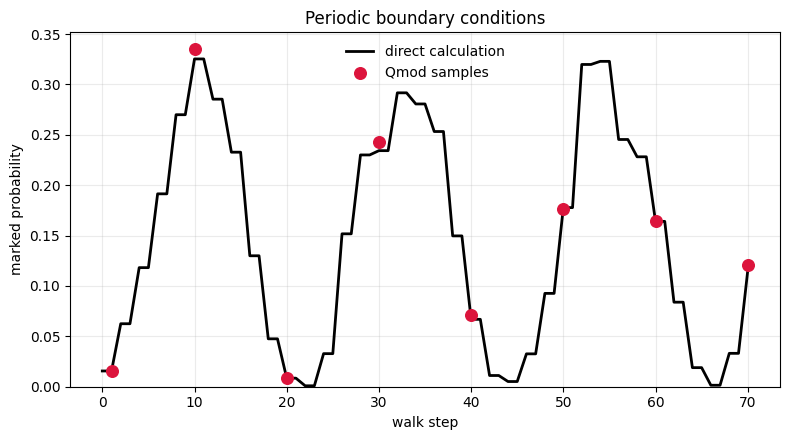

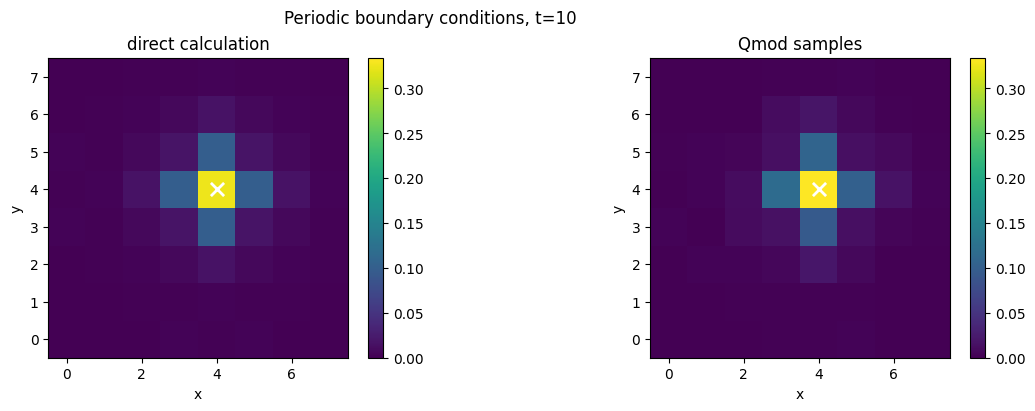

L1 distance at t=10: 0.1190
total variation distance: 0.0595


In [24]:
max_step = max(max(selected_steps), comparison_step)
time_axis = np.arange(max_step + 1)

periodic_direct_curve, periodic_snapshots = simulate_walk_reference(
    "periodic", max_step, snapshots=[comparison_step]
)
periodic_qmod_curve = sample_marked_probabilities(periodic_qprog, selected_steps)
periodic_qmod_distribution, _ = qmod_position_distribution(
    periodic_qprog, comparison_step
)
periodic_direct_distribution = periodic_snapshots[comparison_step]

plot_marked_probability(
    time_axis,
    periodic_direct_curve,
    periodic_qmod_curve,
    "Periodic boundary conditions",
)
plot_probability_maps(
    periodic_direct_distribution,
    periodic_qmod_distribution,
    f"Periodic boundary conditions, t={comparison_step}",
)

periodic_l1 = np.sum(np.abs(periodic_direct_distribution - periodic_qmod_distribution))
print(f"L1 distance at t={comparison_step}: {periodic_l1:.4f}")
print(f"total variation distance: {0.5 * periodic_l1:.4f}")

## Non-periodic Boundary Conditions: Qmod

The non-periodic implementation follows `spatial_search_nonperiodic_fixed.ipynb`.  The important point is that the boundary information is not stored as a persistent quantum register.  Instead, each shift step computes a temporary `allowed` bit from the current `(position, coin)` state, uses it to decide whether the walker can move, and uncomputes it inside `within_apply`.

This avoids the bug where a boundary label prepared at the initial position would move together with the amplitude and stop describing the current vertex.

In [25]:
@qfunc
def mark_allowed_direction(pos: pos_reg, l: QNum, allowed: QBit):
    control((l == 0) & (pos.x > 0), lambda: X(allowed))
    control((l == 1) & (pos.x < L - 1), lambda: X(allowed))
    control((l == 2) & (pos.y > 0), lambda: X(allowed))
    control((l == 3) & (pos.y < L - 1), lambda: X(allowed))


@qfunc
def move_allowed_direction(pos: pos_reg, l: QNum, allowed: QBit):
    control(allowed, lambda: control(l == 0, lambda: shift_minus(pos.x)))
    control(allowed, lambda: control(l == 1, lambda: shift_plus(pos.x)))
    control(allowed, lambda: control(l == 2, lambda: shift_minus(pos.y)))
    control(allowed, lambda: control(l == 3, lambda: shift_plus(pos.y)))


@qfunc
def shift_operator_nonperiodic(pos: pos_reg, l: QNum, allowed: QBit):
    within_apply(
        within=lambda: mark_allowed_direction(pos, l, allowed),
        apply=lambda: [
            move_allowed_direction(pos, l, allowed),
            control(allowed, lambda: flip_operator(l)),
        ],
    )


@qfunc
def quantum_walk_nonperiodic(pos: pos_reg, l: QNum, allowed: QBit):
    coin_operator(l)
    shift_operator_nonperiodic(pos, l, allowed)


@qfunc
def coin_walk_nonperiodic(t: CInt, pos: pos_reg, l: QNum, allowed: QBit):
    power(
        t,
        lambda: [oracle_operator(pos), quantum_walk_nonperiodic(pos, l, allowed)],
    )


@qfunc
def main(t: CInt, p: Output[pos_reg]):
    l = QNum()
    allowed = QBit()
    allocate(p.size, p)
    allocate(nl, l)
    allocate(allowed)
    initial_state(p, l)
    coin_walk_nonperiodic(t, p, l, allowed)
    drop(allowed)
    drop(l)

In [26]:
nonperiodic_qprog = synthesize(main)
# show(nonperiodic_qprog)

### Non-periodic Boundary Conditions: Distribution Check

We now repeat the same comparison with blocked boundary moves.  The direct calculation uses the same blocked-move convention as the Qmod circuit: outward amplitudes stay at the same vertex and do not flip the coin.

Submitting job to simulator
Job: https://platform.classiq.io/jobs/bafc7941-a3e4-4c7c-b702-5c6dc51d835b
Submitting job to simulator


t=  1: counts=   19, probability=0.01855


Job: https://platform.classiq.io/jobs/92dd18a8-b6b1-42ff-900c-75ece4d3e7c3
Submitting job to simulator


t= 10: counts=  313, probability=0.30566


Job: https://platform.classiq.io/jobs/4b1e94ab-ddde-491a-8d6d-96bb19860979
Submitting job to simulator


...

Job: https://platform.classiq.io/jobs/34c8b955-422e-4859-9dba-5a3de2f86037
Submitting job to simulator


t= 60: counts=  236, probability=0.23047


Job: https://platform.classiq.io/jobs/52e12e73-603c-41ae-bbd0-fd0947d3b459
Submitting job to simulator


t= 70: counts=   24, probability=0.02344


Job: https://platform.classiq.io/jobs/d45bd53b-375c-466d-a436-093edb87850e


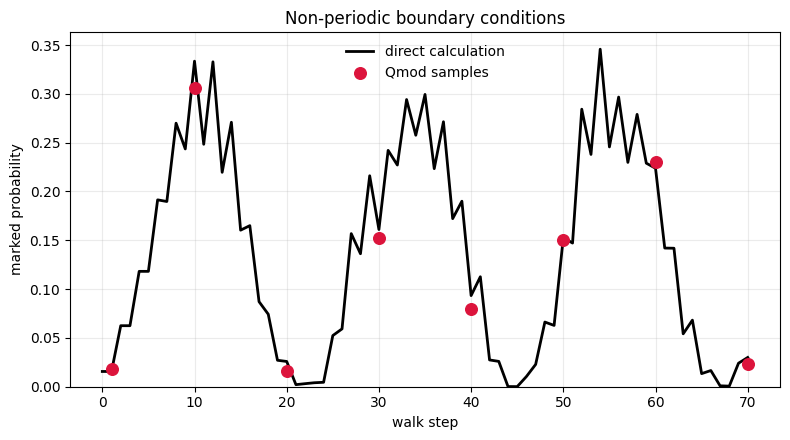

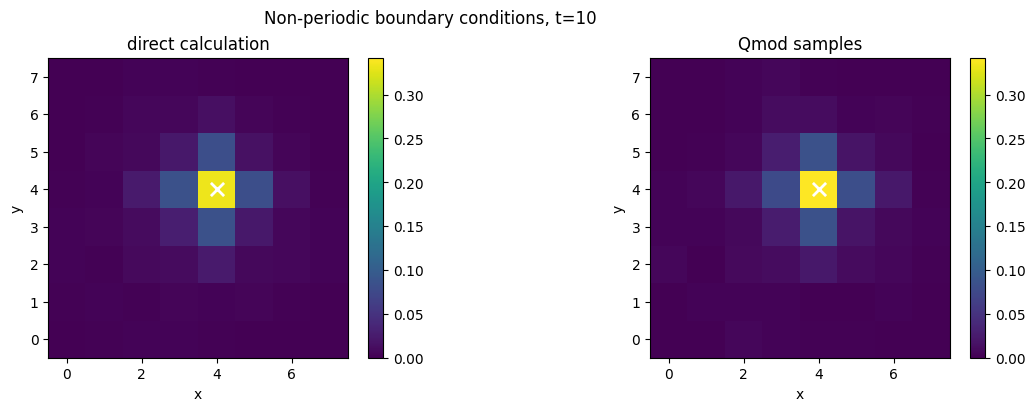

L1 distance at t=10: 0.1161
total variation distance: 0.0581


In [27]:
nonperiodic_direct_curve, nonperiodic_snapshots = simulate_walk_reference(
    "nonperiodic", max_step, snapshots=[comparison_step]
)
nonperiodic_qmod_curve = sample_marked_probabilities(nonperiodic_qprog, selected_steps)
nonperiodic_qmod_distribution, _ = qmod_position_distribution(
    nonperiodic_qprog, comparison_step
)
nonperiodic_direct_distribution = nonperiodic_snapshots[comparison_step]

plot_marked_probability(
    time_axis,
    nonperiodic_direct_curve,
    nonperiodic_qmod_curve,
    "Non-periodic boundary conditions",
)
plot_probability_maps(
    nonperiodic_direct_distribution,
    nonperiodic_qmod_distribution,
    f"Non-periodic boundary conditions, t={comparison_step}",
)

nonperiodic_l1 = np.sum(
    np.abs(nonperiodic_direct_distribution - nonperiodic_qmod_distribution)
)
print(f"L1 distance at t={comparison_step}: {nonperiodic_l1:.4f}")
print(f"total variation distance: {0.5 * nonperiodic_l1:.4f}")

## Summary

The Qmod implementation and the direct statevector calculation use the same oracle, Grover coin, flip-flop shift, marked vertex, and initial state.  For periodic boundaries, the shift wraps around the lattice.  For non-periodic boundaries, each step computes whether the current direction is allowed and blocks outward moves.

The marked-vertex probability curves and the probability-distribution heatmaps provide complementary checks: the curve verifies the spatial-search signal, while the heatmap verifies that the full walk dynamics match the direct calculation up to finite-shot sampling noise.

## Reference

<a id="CoinsMakeQuantumWalksFaster">[1]</a> [Ambainis, A., Kempe, J., and Rivosh, A. "Coins Make Quantum Walks Faster." Proceedings of the 16th Annual ACM-SIAM Symposium on Discrete Algorithms (SODA), 2005.](https://arxiv.org/pdf/quant-ph/0402107)

<a id="ClassiqDiscreteTimeQuantumWalk">[2]</a> [Classiq documentation: "Discrete-time Quantum Walk."](https://docs.classiq.io/explore/tutorials/advanced_tutorials/discrete_quantum_walk_2d/discrete_time_quantum_walk#quantum-walks-on-one-and-two-dimentional-lattice)
```
